# *Chapter 25*<br>   Fluid Dynamics 

| | | |
|:---:|:---:|:---:|
| ![image](Figs/Cover.png)|[From **COMPUTATIONAL PHYSICS**, 3rd Ed, 2015](http://physics.oregonstate.edu/~rubin/Books/CPbook/index.html) <br>RH Landau, MJ Paez, and CC Bordeianu (deceased) <br>Copyrights: <br> [Wiley-VCH, Berlin;](http://www.wiley-vch.de/publish/en/books/ISBN3-527-41315-4/) and [Wiley & Sons, New York](http://www.wiley.com/WileyCDA/WileyTitle/productCd-3527413154.html)<br>  R Landau, Oregon State Unv, <br>MJ Paez, Univ Antioquia,<br> C Bordeianu, Univ Bucharest, 2015.<br> Support by National Science Foundation.|![image](Figs/BackCover.png)|

**25 Fluid Dynamics**<br>
[25.1 River Hydrodynamics](#25.1)<br>
[25.2 Navier-Stokes Equation (Theory)](#25.2)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[25.2.1 Boundary Conditions for Parallel Plates](#25.2.1)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[25.2.2 Analytic Solution for Parallel Plates](#25.2.2)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[25.2.3 Finite-Difference Algorithm and Overrelaxation](#25.2.3)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[25.2.4 Successive Overrelaxation Implementation](#25.2.4)<br>
[25.3 2-D Flow over a Beam](#25.3)<br>
[25.4 Theory: Vorticity Form of Navier-Stokes Equation](#25.4)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[25.4.1 Finite Differences and the SOR Algorithm](#25.4.1)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[25.4.2 Boundary Conditions for a Beam](#25.4.2)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[25.4.3 SOR on a Grid](#25.4.3)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[25.4.4 Flow Assessment](#25.4.4)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[25.4.5 Exploration](#25.4.5)<br>

*We have already introduced some fluid dynamics in the previous
chapter’s discussion of shallow-water solitons. This chapter confronts
the more general equations of computational fluid dynamics (CFD) and
their solutions.*\[*Note:* We acknowledge some helpful reading of by
Satoru S. Kano.\] The mathematical description of the motion of fluids,
although not a new subject, remains a challenging one. The equations are
complicated and nonlinear, there are many degrees of freedom, the
nonlinearities may lead to instabilities, analytic solutions are rare,
and the boundary conditions for realistic geometries (like airplanes)
are not intuitive. These difficulties may explain why fluid dynamics is
often absent from undergraduate and even graduate physics curricula.
Nonetheless, as an essential element of the physical world that also has
tremendous practical importance, we encourage its study. We recommend
\[[Fetter & Walecka(80)](BiblioLinked.html#fet), [Landau & Lifshitz(87)](BiblioLinked.html#LLF)\] for those interested in
the derivations, and \[[Shaw(92)](BiblioLinked.html#shaw)\] for more details about the
computations.

** This Chapter’s Lecture, Slide Web Links, Applets & Animations** 

| | |
|---|---|
|[All Lectures](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/index.html)|[![anything](Figs/RHLlectureMod4.png)](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/index.html)|

| *Lecture (Flash)*| *Slides* | *Sections*|*Lecture (Flash)*| *Slides* | *Sections*|  
|- - -|:- - -:|:- - -:|- - -|:- - -:|:- - -:|
|[Shocks & Solitons](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/SolitonShock/SolitonShock.html)|[pdf](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Slides/Slides_NoAnimate_pdf/ShockSoliton.pdf)|19.3 | [Computational Fluid Dynamics](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/FluidDynamics/Hydro.html)|[pdf](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Slides/Slides_NoAnimate_pdf/CFD_24Jun10.pdf)| 19.6 |
|[Solitons Applet](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook/Applets/index.html)|-|19.5 |[2-D Solitons Applet](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook/Movies/2dsol.mp4)|-| 19.5 | 
|[Smoothed Particle Hydrodynamics](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook/Applets/index.html)|-|19.6-19.9 |[Shock Waves](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook/Applets/index.html)|-| 19.3 |

## 25.1  River Hydrodynamics <a id="25.1"></a>

**Problem:** In order to give migrating salmon a place to rest during
their arduous upstream journey, the Oregon Department of Environment is
placing objects in several deep, wide, fast-flowing streams. One such
object is a long beam of rectangular cross section (Figure 25.1 left),
and another is a set of plates (Figure 19.4 right). The objects are to
be placed far enough below the water’s surface so as not to disturb the
surface flow, and far enough from the bottom of the stream so as not to
disturb the flow there either. Your **problem** is to determine the
spatial dependence of the stream’s velocity when the objects are in
place, and, specifically, whether the wake of the object will be large
enough to provide a resting place for a meter-long salmon.

## 25.2  Navier-Stokes Equation (Theory) <a id="25.2"></a>

As with our study of shallow-water waves, we assume that water is
*incompressible* and thus that its density $\rho$ is constant. We also
simplify the theory by looking only at steady-state situations, that is,
ones in which the velocity is not a function of time. However, to
understand how water flows around objects, like our beam, it is
essential to include the complication of frictional forces
(*viscosity*).

![image](Figs/Fig25_1.png)

**Figure 25.1** Side view of the flow of a stream around a submerged beam
(*left*) and around two parallel plates (*right*). Both beam and plates have
length $\textit{L}$ along the direction of flow. The flow is seen to be symmetric
about the centerline and to be unaffected at the bottom and at the surface by
the submerged object.

For the sake of completeness, we repeat here the first equation of
hydrodynamics, the continuity equation (24.2):

$$\tag*{25.1}
\frac{\partial\rho(\mathbf{x},t)}{\partial t} + \vec{\nabla}\cdot \mathbf{j} = 0, 
\quad  \mathbf{j}  =  \rho \mathbf{v}(\mathbf{x}, t).$$

Before proceeding to the second equation, we introduce a special time
derivative, the *hydrodynamic* derivative $D\mathbf{v}/Dt$, which is
appropriate for a quantity contained in a moving fluid \[[Fetter &
Walecka(80)](BiblioLinked.html#fet)\]:

$$\tag*{25.2}
\frac{D\mathbf{v}}{Dt}  =  (\mathbf{v}\cdot\vec{\nabla})
\mathbf{v} + \frac{\partial\mathbf{v}} {\partial t}.$$

This derivative gives the rate of change, as viewed from a stationary
frame, of the velocity of material in *an element of flowing fluid* and
so incorporates changes as a result of the motion of the fluid (first
term) as well as any explicit time dependence of the velocity. Of
particular interest is that $D\mathbf{v}/Dt$ is second order in the
velocity, and so its occurrence introduces nonlinearities into the
theory. You may think of these nonlinearities as related to the
fictitious (inertial) forces that occur when we describe the motion in
the fluid’s rest frame (an accelerating frame to us).

The material derivative is the leading term in the *Navier-Stokes equation*,

$$\begin{align} \tag*{25.3}
 \frac{D\mathbf{v}}{Dt} &=
\nu\nabla^2\mathbf{v} - \frac{1}{\rho}\vec{\nabla}
P(\rho,T,x), \\
\frac{\partial v_x}{\partial t} + \sum_{j=x}^z v_j
\frac{\partial v_x}{\partial x_j} &=  \nu \sum_{j=x}^z
\frac{\partial^2v_x}{\partial x_j^2} - \frac{1}{\rho}
\frac{\partial P}{\partial x} ,   \nonumber \\
\frac{\partial v_y}{\partial t} + \sum_{j=x}^z v_j
\frac{\partial v_y}{\partial x_j} &= \nu \sum_{j=x}^z
\frac{\partial^2v_y}{\partial x_j^2} - \frac{1}{\rho}
\frac{\partial P}{\partial y} ,\tag*{25.4}\\
\frac{\partial v_z}{\partial t} + \sum_{j=x}^z v_j
\frac{\partial v_z}{\partial x_j} &= \nu \sum_{j=x}^z
\frac{\partial^2v_z} {\partial x_j^2} - \frac{1}{\rho}
\frac{\partial P} {\partial z}.\nonumber\end{align}$$

Here $\nu$ is the kinematic viscosity, $P$ is the pressure, and (25.4) gives the
derivatives in (25.3) in Cartesian coordinates. This equation describes transfer of
the momentum of the fluid within some region of space as a result of forces and
flow (think $d\mathbf{p}/dt = \mathbf{F}$). There is a simultaneous equation
for each of the three velocity components.
The $\mathbf{v}\cdot\nabla\mathbf{v}$ term in $D\mathbf{v}/Dt$ describes
transport of momentum in some region of space resulting from the fluid’s flow
and is often called the *convection* or *advection* term.\[*Note:* We discuss
pure advection in §24.1. In oceanology or meteorology, convection implies the
transfer of mass in the vertical direction where it overcomes gravity, whereas
advection refers to transfer in the horizontal direction.\] The $\vec{\nabla} P$
term describes the velocity change as a result of pressure changes, and the
$\nu\nabla^2 \mathbf{v}$ term describes the velocity change resulting from
viscous forces (which tend to dampen the flow).

The explicit functional dependence of the pressure on the fluid’s density and
temperature $P(\rho,T,x)$ is known as the *equation of state of the fluid*, and
would have to be known before trying to solve the Navier-Stokes equation.

$$\begin{align}
\tag*{25.5}
\vec{\nabla} \cdot \mathbf{v} &\equiv  \sum_i \frac{\partial v_i} {\partial x_i} =
0,\\
 (\mathbf{v} \cdot \vec{\nabla})\mathbf{v} &=
\nu\nabla^2\mathbf{v} - \frac{1}{\rho}  \vec{\nabla} P.\tag*{25.6}\end{align}$$

The first equation expresses the equality of inflow and outflow and is known as
the *condition of incompressibility*. In as much as the stream in our problem is
much wider than the width ($z$ direction) of the beam, and because we are
staying away from the banks, we will ignore the $z$ dependence of the velocity.
The explicit PDE’s we need to solve then reduce to:

$$\begin{align} \tag*{25.7}
 &\displaystyle {\frac{\partial v_x} {\partial x} +
\frac{\partial v_y} {\partial y}\ = \ 0}, &\\
 &  \nu \left( \frac{\partial^2 v_x} {\partial x^2} +
\frac{\partial^2 v_x} {\partial y^2}\right) \ = \  v_x
\frac{\partial v_x} {\partial x} + v_y    \frac{\partial v_x}
{\partial y} + \frac{1} {\rho} \frac{\partial P} {\partial x}, &\tag*{25.8}\\
 & \nu
\left(\frac{\partial^2 v_y} {\partial x^2} + \frac{\partial^2 v_y} {\partial
y^2}\right)
\ = \  v_x   \frac{\partial v_y} {\partial x} + v_y    \frac{\partial
v_y} {\partial y} + \frac{1}{\rho} \frac{\partial P} {\partial y}. &
\tag*{25.9}\end{align}$$

### 25.2.1  Boundary Conditions for Parallel Plates<a id="25.2.1"></a>

The plate problem is relatively easy to solve analytically, and so we
will do it! This will give us some experience with the equations as well
as a check for our numerical solution. To find a unique solution to the
PDE’s (25.7)-(25.9), we need to specify boundary conditions. As far as
we can tell, picking boundary conditions is somewhat of an acquired
skill.

We assume that the submerged parallel plates are placed in a stream that
is flowing with a constant velocity $V_0$ in the horizontal direction
(Figure 25.1 right). If the velocity $V_0$ is not too high or the
kinematic viscosity $\nu$ is sufficiently large, then the flow should be
smooth and without turbulence. We call such flow *laminar*. Typically, a
fluid undergoing laminar flow moves in smooth paths that do not close on
themselves, like the smooth flow of water from a faucet. If we imagine
attaching a vector to each element of the fluid, then the path swept out
by that vector is called a *streamline* or *line of motion* of the
fluid. These streamlines can be visualized experimentally by adding
colored dye to the stream. We assume that the plates are so thin that
the flow remains laminar as it passes around and through them.

![image](Figs/Fig25_2.png)

**Figure 25.2** The boundary conditions for two thin submerged plates. The
surrounding box is the integration volume within which we solve the PDE’s and
upon whose surface we impose the boundary conditions. In practice the box is
much larger than $\textit{L}$ and $\textit{H}$.

If the plates are thin, then the flow upstream of them is not affected,
and we can limit our solution space to the rectangular region in
Figure 25.2. We assume that the length $L$ and separation $H$ of the
plates are small compared to the size of the stream, so the flow returns
to uniform as we get far downstream from the plates. As seen in Figure
25.2 there are boundary conditions at the *inlet* where the fluid enters
the solution space, at the *outlet* where it leaves, and at the
stationary plates. In addition, because the plates are far from the
stream’s bottom and surface, we assume that the dotted-dashed centerline
is a plane of symmetry, with identical flow above and below the plane.
We thus have four different types of boundary conditions to impose on
our solution:

**Solid plates:** Because there is friction (viscosity) between the
fluid and the plate surface, the only way to have laminar flow is to
have the fluid’s velocity equal to the plate’s velocity, which means
both are zero:

$$\tag*{25.10} v_x = v_y = 0.$$

Such being the case, we have smooth flow in which the negligibly thin
plates lie along streamlines of the fluid (like a “streamlined”
vehicle).

**Inlet:**  The fluid enters the integration domain at the inlet with a
horizontal velocity $V_0$. Because the inlet is far upstream from the
plates, we assume that the fluid velocity at the inlet is unchanged by
the presence of the plates:

$$v_x = V_0, \qquad v_y = 0.\tag*{25.11}$$

**Outlet:** Fluid leaves the integration domain at the outlet. While it
is totally reasonable to assume that the fluid returns to its
unperturbed state there, we are not told what that is. So, instead, we
assume that there is a physical outlet at the end with the water just
shooting out of it. Consequently, we assume that the water pressure
equals zero at the outlet (as at the end of a garden hose) and that the
velocity does not change in a direction normal to the outlet:

$$\tag*{25.12}
 P = 0, \qquad
 \frac{\partial v_x} {\partial x} =  \frac{\partial v_y} {\partial x} =0.$$

**Symmetry plane:** If the flow is symmetric about the $y=0$ plane, then
there cannot be flow through the plane, and the spatial derivatives of
the velocity components normal to the plane must vanish:

$$\tag*{25.13}
        v_y = 0,    \qquad
 \frac{\partial v_y} {\partial y} =0.$$

This condition follows from the assumption that the plates are along
streamlines and that they are negligibly thin. It means that all the
streamlines are parallel to the plates as well as to the water surface,
and so it must be that $v_y=0$ everywhere. The fluid enters in the
horizontal direction, the plates do not change the vertical $y$
component of the velocity, and the flow remains symmetric about the
centerline. There is a retardation of the flow around the plates as a
result of the viscous nature of the flow and as a result of the
$\mathbf{v}=0$ boundary layers formed on the plates, but there are no
actual $v_y$ components.

### 25.2.2  Finite-Difference Algorithm and Overrelaxation<a id="25.2.2"></a>

Now we develop an algorithm for solution of the Navier-Stokes and continuity
PDE’s using successive overrelaxation. This is a variation of the method used in
[Chapter 19, *Electrostatics via Finite Differences*](CP19.ipynb), to solve
Poisson’s equation. We divide space into a rectangular grid with the spacing $h$
in both the $x$ and $y$ directions:

$$\begin{align} x = i h, \quad i =0, \ldots,
N_x;\qquad y = j h, \quad j =0,
\ldots, N_y.\end{align}$$

We next express the derivatives in
(25.7)-(25.9) as finite differences of the values of the velocities at
the grid points using central-difference approximations. For $\nu =
1 \mbox{m}^2/\mbox{s}$ and $\rho = 1 \mbox{kg/m}^3$, this yields

$$\begin{align}
\tag*{25.14}
v^x _{i + 1,j} - v^x _{i - 1,j} + v^y _{i,j + 1} - v^y_{i,j - 1} = 0, &\\
v^x _{i+1,j} + v^x _{i-1,j} + v^x _{i,j+1} + v^x _{i,j-1} -4v^x_{i,j} 
 & = \\
 \frac{h} { 2} v^x _{i,j}\left[ {v^x _{i + 1,j} - v^x _{i - 1,j}} \right] + \frac{h} { 2} v^y
_{i,j}\left[ {v^x _{i,j + 1} - v^x _{i,j - 1}} \right]
 + \frac{h}{ 2}
\left[{P_{i+1,j} - P_{i-1,j}}\right],\tag*{25.15}  &\\
v^y _{i + 1,j} + v^y _{i - 1,j} + v^y _{i,j + 1} + v^y _{i,j - 1} - 4 v^y
_{i,j}   = \frac{h} { 2} v^x _{i,j}\left[ v^y _{i + 1,j} - v^y _{i - 1,j} \right]
+\frac{h} { 2} v^y _{i,j}\left[ v^y _{i,j + 1} - v^y _{i,j - 1} \right] 
+ \frac{h} { 2} \left[ {P_{i,j + 1} - P_{i,j - 1}}\right].\tag*{25.16}
     \end{align}$$

Because $v^y\equiv 0$ for this problem, we rearrange terms to obtain for
$v^x$:

$$\begin{align} 4 v^x _{i,j} &= v^x _{i + 1,j} + v^x _{i - 1,j} + v^x _{i,j + 1} + v^x _{i,j
- 1} - \frac{h} { 2} v^x_{i,j} \left[v^x _{i + 1,j} - v^x _{i - 1,j} \right] \\
 & \quad- \frac{h} { 2} v^y _{i,j}\left[v^x _{i,j + 1} - v^x _{i,j - 1}
\right] - \frac {h} { 2} \left[P_{i + 1,j} - P_{i - 1,j}\right] .\tag*{25.17}\end{align}$$

We recognize in (24.24) an algorithm similar to the one we used in solving
Laplace’s equation by relaxation. Indeed, as we did there, we can accelerate the
convergence by writing the algorithm with the new value of $v^x$ given as the
old value plus a correction (residual):

$$\begin{align}
\tag*{25.18}
v^x _{i,j} & =     v^x _{i,j} + r_{i,j}, \quad r  =  v^{x
\rm{(new)}}_{i,j} - v^{x \rm{(old)}}_{i,j}\\
\Rightarrow\quad r & =  \frac{1}{4}\left\{v^x _{i + 1,j} + v^x_{i
- 1,j} + v^x_{i,j + 1} + v^x _{i,j - 1} - \frac{h}{2} v^x _{i,j}
\left[ {v^x _{i + 1,j} - v^x _{i - 1,j}} \right] \right. \nonumber\\
\qquad &-  \left. \frac{h}{2} v^y _{i,j}\left[{v^x_{i,j + 1} - v^x_{i,j -
1}} \right]- \frac{h}{2} \left[{P_{i + 1,j} - P_{i - 1,j}} \right]
\right\}- v^x _{i,j}\tag*{25.19}\end{align}$$

As performed with the
Poisson equation algorithm, successive iterations sweep the interior of
the grid, continuously adding in the residual (25.18) until the change
becomes smaller than some set level of tolerance,
$\left| {r_{i,j}} \right| < \varepsilon$.

A variation of this method, *successive overrelaxation*, increases the speed at
which the residuals approach zero via an amplifying factor $\omega$:

$$\begin{align}
 \tag*{25.20}
v^x _{i,j} = v^x _{i,j} + \omega r_{i,j} \quad \mbox{(SOR)}.\end{align}$$
The
standard relaxation algorithm (25.18) is obtained with $\omega=1$, an
accelerated convergence (*overrelaxation*) is obtained with $\omega\ge 1$,
and *underrelaxation* occurs for $\omega <1$. Values $\omega>2$ are found
to lead to numerical instabilities. Although a detailed analysis of the algorithm is
necessary to predict the optimal value for $\omega$, we suggest that you test
different values for $\omega$ to see which one provides the fastest
convergence for your problem.

Working, wait for the figure after 100 iterations.
10
20
30
40
50
60
70
80
90
100


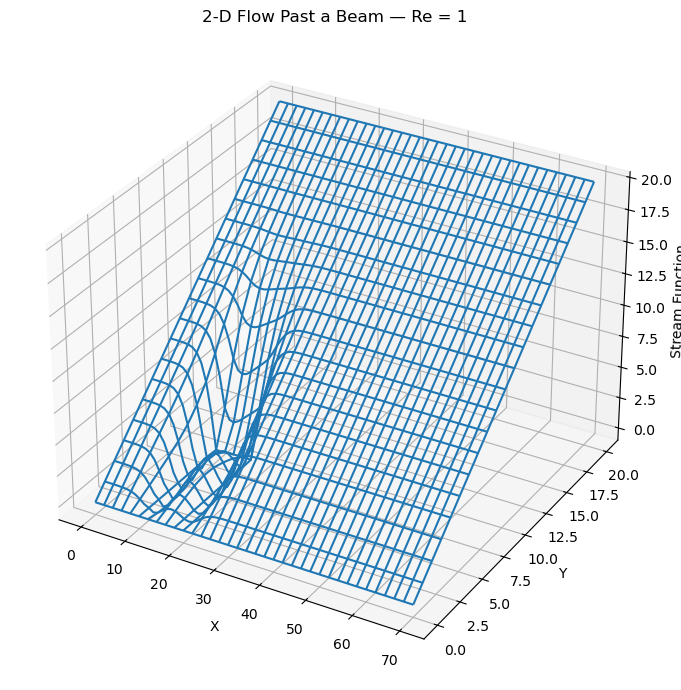

In [13]:

"""
Beam.py
-------
2-D incompressible Navier-Stokes flow past a rectangular beam,
formulated using the streamfunction-vorticity method.

Originally written for an older VPython/IPython environment.
Modernized for Python 3, NumPy, and Matplotlib.
"""

import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Simulation parameters
# ---------------------------------------------------------------------------

NX = 70
NY = 20

IL = 10       # Beam leading-edge x-index
H = 8         # Beam height in grid cells
T = 8         # Beam thickness in grid cells
h = 1.0       # Grid spacing

V0 = 1.0      # Inlet velocity
omega = 0.1   # Relaxation parameter
nu = 1.0      # Kinematic viscosity

Re = V0 * h / nu

MAX_ITER = 100


# ---------------------------------------------------------------------------
# Fields
# ---------------------------------------------------------------------------

# u is actually the streamfunction, not the velocity.
# w is the vorticity.
stream = np.zeros((NX + 1, NY + 1), dtype=float)
vorticity = np.zeros((NX + 1, NY + 1), dtype=float)


# ---------------------------------------------------------------------------
# Boundary conditions
# ---------------------------------------------------------------------------

def apply_boundaries():
    """Initialize and apply the outer boundary conditions."""

    # Initial streamfunction and vorticity.
    vorticity.fill(0.0)

    # Uniform inlet flow:
    # psi = V0 * y
    y = np.arange(NY + 1)
    stream[:, :] = V0 * y[np.newaxis, :]

    # Upper fluid boundary.
    stream[:, NY] = stream[:, NY - 1] + V0 * h
    vorticity[:, NY - 1] = 0.0

    # Inlet.
    stream[1, :] = stream[0, :]
    vorticity[0, :] = 0.0

    # Outlet: zero-gradient condition.
    vorticity[NX, 1:NY] = vorticity[NX - 1, 1:NY]
    stream[NX, 1:NY] = stream[NX - 1, 1:NY]


def apply_beam_boundary():
    """Apply no-slip boundary conditions on the rectangular beam."""

    # Front face.
    for j in range(H + 1):
        vorticity[IL, j] = (
            -2.0 * stream[IL - 1, j] / h**2
        )

    # Rear face.
    for j in range(H + 1):
        vorticity[IL + T, j] = (
            -2.0 * stream[IL + T + 1, j] / h**2
        )

    # Upper face.
    for i in range(IL, IL + T + 1):
        vorticity[i, H - 1] = (
            -2.0 * stream[i, H] / h**2
        )

    # Streamfunction = constant on solid boundaries.
    stream[IL, :H + 1] = 0.0
    stream[IL + T, :H + 1] = 0.0
    stream[IL:IL + T + 1, H] = 0.0


# ---------------------------------------------------------------------------
# Relaxation
# ---------------------------------------------------------------------------

def relax():
    """Perform one relaxation sweep for streamfunction and vorticity."""

    apply_beam_boundary()

    # Interior points:
    # i = 1, ..., NX-1
    # j = 1, ..., NY-1
    center = (slice(1, NX), slice(1, NY))


    psi_new = (
        stream[2:NX + 1, 1:NY]
        + stream[0:NX - 1, 1:NY]
        + stream[1:NX, 2:NY + 1]
        + stream[1:NX, 0:NY - 1]
        + h**2 * vorticity[1:NX, 1:NY]
    ) / 4.0

    stream[center] += omega * (
        psi_new - stream[center]
    )

    # -----------------------------------------------------------------------
    # Relax vorticity.
    # -----------------------------------------------------------------------

    a1 = (
        vorticity[2:NX + 1, 1:NY]
        + vorticity[0:NX - 1, 1:NY]
        + vorticity[1:NX, 2:NY + 1]
        + vorticity[1:NX, 0:NY - 1]
    )

    a2 = (
        (stream[1:NX, 2:NY + 1] - stream[1:NX, 0:NY - 1])
        * (vorticity[2:NX + 1, 1:NY] - vorticity[0:NX - 1, 1:NY])
    )

    a3 = (
        (stream[2:NX + 1, 1:NY] - stream[0:NX - 1, 1:NY])
        * (vorticity[1:NX, 2:NY + 1] - vorticity[1:NX, 0:NY - 1])
    )

    vorticity_new = (
        a1 - (Re / 4.0) * (a2 - a3)
    ) / 4.0

    vorticity[center] += omega * (
        vorticity_new - vorticity[center]
    )


# ---------------------------------------------------------------------------
# Main simulation
# ---------------------------------------------------------------------------

def main():
    print("Working, wait for the figure after 100 iterations.")

    apply_boundaries()

    for iteration in range(1, MAX_ITER + 1):
        if iteration % 10 == 0:
            print(iteration)

        relax()

    # Normalize streamfunction by V0*h.
    stream_normalized = stream / (V0 * h)

    # -----------------------------------------------------------------------
    # Plot
    # -----------------------------------------------------------------------

    # The original code used range(NX - 1), which does not correspond to
    # the actual field dimensions. Use the complete grid here.
    x = np.arange(NX + 1)
    y = np.arange(NY + 1)

    X, Y = np.meshgrid(x, y, indexing="ij")

    Z = stream_normalized

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_wireframe(X, Y, Z)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Stream Function")

    ax.set_title(
        f"2-D Flow Past a Beam — Re = {Re:g}"
    )

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


### 25.2.3  Successive Overrelaxation Implementation<a id="25.2.3"></a>

1.  Modify the program `Beam.py`, or write your own, to solve the
    Navier-Stokes equation for the velocity of a fluid in 2-D flow.
    Represent the $x$ and $y$ components of the velocity by the arrays
    `vx[Nx,Ny]` and `vy[Nx,Ny]`.

2.  Specialize your solution to the rectangular domain and boundary
    conditions indicated in Figure  25.2.

3. Use of the following parameter values,

    $$\begin{align}
    \nu & =  1 \mbox{ m}^2/\mbox{s}, \quad \rho   =
    10^3 \mbox{kg/m}^3, \quad \mbox{(flow
    parameters),}\\
    N_x & =  400, \quad N_y = 40, \ \ h  = 1, \quad \mbox{(grid
    parameters)},\end{align}$$

    leads to the analytic solution (not
    derived here)

    $$\tag*{25.21}
    \frac{\partial P} {\partial x} = -{12}, \quad \frac{\partial P}
    {\partial y} =0, \quad v^x = \frac{3j}{20} \left(1- \frac{j}{40}
    \right), \quad v^y = 0.$$

4.  For the relaxation method, output the iteration number and the
    computed $v^x$ and then compare the analytic and numeric results.

5.  Repeat the calculation and see if SOR speeds up the convergence.

## 25.3  2-D Flow over a Beam<a id="25.3"></a>

Now that the comparison with an analytic solution has shown that our CFD
simulation works, we return to determining if the beam in Figure 25.1
might produce a good resting place for salmon. While we have no analytic
solution with which to compare, our canoeing and fishing adventures have
taught us that *standing waves* with fish in them are often formed
behind rocks in streams, and so we expect there will be a standing wave
formed behind the beam.

## 25.4  Theory: Vorticity Form of Navier-Stokes Equation <a id="25.4"></a>

We have seen how to solve numerically the hydrodynamics equations

$$\begin{align}
\tag*{25.22}
\vec{\nabla} \cdot \mathbf{v} &= 0, \\
 (\mathbf{v} \cdot \vec{\nabla})\mathbf{v} & = - \frac{1} { \rho} \vec{\nabla} P +
\nu\nabla^2\mathbf{v}. \tag*{25.23}
 \end{align}$$

These equations determine the components of a fluid’s
velocity, pressure, and density as functions of position. In analogy to
electrostatics, where one usually solves for the simpler scalar
potential and then takes its gradient to determine the more complicated
vector field, we now recast the hydrodynamic equations into forms that
permit us to solve two simpler equations for simpler functions, from
which the velocity is obtained via a gradient operation.\[*Note:* If we
had to solve only the simpler problem of *irrotational flow* (no
turbulence), then we would be able to use a scalar velocity potential,
in close analogy to electrostatics \[[Lamb(93)](BiblioLinked.html#lamb)\]. For the more general
*rotational flow*, two vector potentials are required.\]

We introduce the *stream function* $\mathbf{u}(\mathbf{x})$ from which
the velocity is determined by the curl operator:

$$\tag*{25.24}
 {\mathbf{v}  =  \vec{\nabla} \times\mathbf{u}(\mathbf{x})}
= \hat{{\epsilon}}_x\left( \frac{\partial u_z}{\partial y} - \frac
{\partial u_y} {\partial z}\right) + \hat{{\epsilon}}_y\left(
\frac{\partial u_x}{\partial z} -\frac{\partial u_z} {\partial
x}\right).$$

Note the absence of the $z$ component of velocity $\mathbf{v}$ for our
problem. Because $\vec{\nabla}\cdot(\vec{\nabla}\times
\mathbf{u})\equiv 0$, we see that any $\mathbf{v}$ that can be written
as the curl of $\mathbf{u}$ automatically satisfies the continuity
equation $\vec{\nabla} \cdot \mathbf{v} = 0$. Further, because
$\mathbf{v}$ for our problem has only $x$ and $y$ components,
$\mathbf{u}(\mathbf{x})$ needs have only a $z$ component:

$$\tag*{25.25} u_z\equiv u \quad \Rightarrow \quad v_x = \frac{{\partial
u}}{{\partial y}},\quad v_y = - \frac{{\partial u}}{{\partial x}}.$$

It is worth noting that in 2-D flows, the contour lines $u =$ constant
are the *streamlines*.

The second simplifying function is the *vorticity* field
$\mathbf{w}(\mathbf{x})$, which is related physically and alphabetically
to the angular velocity $\mathbf{\omega}$ of the fluid. Vorticity is
defined as the curl of the velocity (sometimes with a $-$ sign):

$$\tag*{25.26}
 \mathbf{w}  =  \vec{\nabla} \times
\mathbf{v}(\mathbf{x}).$$

Because the velocity in our problem does not change in the $z$
direction, we have

$$\tag*{25.27} w_z = \left( \frac{\partial v_y} { \partial x} - \frac{\partial v_x} {
\partial y}\right).$$

Physically, we see that the vorticity is a measure of how much the
fluid’s velocity curls or rotates, with the direction of the vorticity
determined by the right-hand rule for rotations. In fact, if we could
pluck a small element of the fluid into space (so it would not feel the
internal strain of the fluid), we would find that it is rotating like a
solid with angular velocity $\mathbf{\omega} \propto \mathbf{w}$
\[[Lamb(93)](BiblioLinked.html#lamb)\]. That being the case, it is useful to think of the
vorticity as giving the local value of the fluid’s angular velocity
vector. If $\mathbf{w}=0$, we have *irrotational* flow.

The field lines of $w$ are continuous and move as if attached to the
particles of the fluid. A uniformly flowing fluid has vanishing curl,
while a nonzero vorticity indicates that the current curls back on
itself or rotates. From the definition of the stream function (25.24),
we see that the vorticity $\mathbf{w}$ is related to it by

$$\tag*{25.28}
\mathbf{w} =  \vec{\nabla} \times \mathbf{v} =
\vec{\nabla}\times(\vec{\nabla}\times \mathbf{u})  = \vec{\nabla}
(\vec{\nabla}\cdot \mathbf{u}) -
\nabla^2\mathbf{u},$$

where we have used a vector identity for $\vec{\nabla}\times(\vec {\nabla}
\times \mathbf{u} )$. Yet the divergence $\vec{\nabla}\cdot \mathbf{u} =0$
because $\mathbf{u}$ has only a $z$ component and that component does not
vary with $z$ (or because there is no source for $\mathbf{u}$). We have now
obtained the basic relation between the stream function $\mathbf{u}$ and the
vorticity $\mathbf{w}$:

$$\begin{align}
\tag*{25.29}
  \vec{\nabla}^2 \mathbf{u} =
-\mathbf{w}.\end{align}$$

 Equation (25.29) is analogous to Poisson’s equation
of electrostatics, $\nabla^2\phi=-4\pi\rho$, only now each component of
vorticity $\mathbf{w}$ is a source for the corresponding component of the
stream function $\mathbf{u}$. If the flow is irrotational, that is, if
$\mathbf{w}=0$, then we need only solve Laplace’s equation for each
component of $u$. Rotational flow, with its coupled nonlinearities equations,
leads to more interesting behavior.

As is to be expected from the definition of $\mathbf{w}$, the vorticity
form of the Navier-Stokes equation is obtained by taking the curl of the
velocity form, that is, by operating on both sides with
$\vec{\nabla}\times$. After significant manipulations one obtains

$$\tag*{25.30}
\nu \nabla^2 \mathbf{w} = [(\vec{\nabla} \times \mathbf{u}) \cdot
\vec{\nabla} ]\mathbf{w}.$$

This and (25.29) are the two simultaneous PDE’s that we need to solve.
In 2-D, with $\mathbf{u}$ and $\mathbf{w}$ having only $z$ components,
they are

$$\begin{align}
 \tag*{25.31}
  \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}  &= -w,  \\
  \nu \left( \frac{\partial^2 w} {\partial x^2}+  \frac{\partial^2 w} {\partial y^2} \right)  &=
\frac{\partial u}{\partial y} \frac{\partial w}{\partial
x} - \frac{\partial u}{\partial x} \frac{\partial w}{\partial y}.
\tag*{25.32}\end{align}$$

So after all that work, we end up with two simultaneous, nonlinear,
elliptic PDE’s that look like a mixture of Poisson’s equation with the
wave equation. The equation for $u$ is Poisson’s equation with source
$w$, and must be solved simultaneously with the second. It is this
second equation that contains mixed products of the derivatives of $u$
and $w$ and thus introduces the nonlinearity.

## 25.4  Finite Differences and the SOR Algorithm<a id="25.4"></a>

We solve (25.31) and (25.32) on an $N_x\times
N_y$ grid of uniform spacing $h$ with

$$\tag*{25.33} x = i\Delta x = ih, \quad i=0,\ldots, N_x, \quad y = j\Delta y =
jh,\quad j=0,\ldots, N_y.$$

Because the beam is symmetric about its centerline (Figure 25.1 left),
we need the solution only in the upper half-plane. We apply the now
familiar central-difference approximation to the Laplacians of $u$ and
$w$ to obtain the difference equation

$$\tag*{25.34}
\frac{{\partial^2 u}}{{\partial x^2 }} + \frac{{\partial^2
u}}{{\partial y^2 }} \simeq\frac{u_{i + 1,j} + u_{i - 1,j} +
u_{i,j + 1} + u_{i,j - 1} - 4 u_{i,j} } { h^2}.$$

Likewise, for the product of first derivatives,

$$\tag*{25.35}
\frac{\partial u} {\partial y} \frac{\partial w} {\partial x}
\simeq\frac{u_{i,j+1}-u_{i,j-1}}{2h} \frac{w_{i+1,j}-w_{i-1,j}}{2h}.$$

The difference form of the vorticity Navier-Stokes equation (25.31)
becomes

$$\begin{align}
\tag*{25.36}
u_{i,j} &= \frac{1}{4} \left(u_{i + 1,j} + u_{i - 1,j} + u_{i,j + 1} + u_{i,j - 1} + h^2
w_{i,j}\right),\\
 w_{i,j}
&= \frac{1}{4} (w_{i + 1,j} + w_{i - 1,j} + w_{i,j + 1} + w_{i,j - 1}) -
\frac{R}{16}\left\{ \left[ u_{i,j + 1} - u_{i,j - 1} \right] \right. \nonumber \\
 & \quad \times \left.\left[ w_{i + 1,j} - w_{i - 1,j} \right] - \left[ u_{i + 1,j} - u_{i - 1,j}
\right]\left[ w_{i,j + 1} - w_{i,j - 1}
\right] \right\},\tag*{25.37}\\
R &= \frac{1}{\nu} \quad = \frac{V_0h}{\nu} \mbox{(in normal
units}.\tag*{25.38}\end{align}$$

Note that we have placed $u_{i,j}$ and $w_{i,j}$ on the LHS of the
equations in order to obtain an algorithm appropriate to solution by
relaxation.

The parameter $R$ in (25.38) is related to the *Reynolds number*. When
we solve the problem in natural units, we measure distances in units of
grid spacing $h$, velocities in units of initial velocity $V_0$, stream
functions in units of $V_0h$, and vorticity in units of $V_0/h$. The
second form is in regular units and is dimensionless. This $R$ is known
as the *grid Reynolds number* and differs from the physical $R$, which
has a pipe diameter in place of the grid spacing $h$.

The grid Reynolds number is a measure of the strength of the coupling of
the nonlinear terms in the equation. When the physical $R$ is small, the
viscosity acts as a frictional force that damps out fluctuations and
keeps the flow smooth. When $R$ is large ($R \simeq 2000$), physical
fluids undergo phase transitions from laminar to turbulent flow in which
turbulence occurs at a cascading set of smaller and smaller space scales
\[[Reynolds(83)](BiblioLinked.html#reynolds), [Falkovich & Sreenivasan(06)](BiblioLinked.html#FS)\]. However, simulations that
produce the onset of turbulence have been a research problem because
Reynolds first experiments in 1883, possibly because laminar flow is
stable against small perturbations and some large-scale “kick” may be
needed to change laminar to turbulent flow. Recent research along these
lines have been able to find unstable, traveling-wave solutions to the
Navier-Stokes equations, and the hope is that these may lead to a
turbulent transition \[[Fitzgerald(04)](BiblioLinked.html#PhysToday)\].

As discussed in §sec24.5, the finite-difference algorithm can have its
convergence accelerated by the use of successive overrelaxation (25.36):

$$\tag*{25.39} u_{i,j} = u_{i,j} + \omega r^{(1)}_{i,j}, \qquad w_{i,j} = w_{i,j} +
\omega r^{(2)}_{i,j}\quad\mbox{(SOR)}.$$

Here $\omega$ is the overrelaxation parameter and should lie in the
range $0 <\omega<2$ for stability. The residuals are just the changes in
a single step, $r^{(1)}= u^{\rm{new}}    -
u^{\rm{old}}$ and $r^{(2)}=w^{\rm{new}} - w^{\rm{old}}$:

$$\begin{align} r^{(1)}_{i,j} &= \frac{1}{4} \left(u_{i + 1,j} + u_{i - 1,j} + u_{i,j + 1}
+ u_{i,j - 1} + w_{i,j} \right) - u_{i,j},\nonumber \\
 r^{(2)}_{i,j} &= \frac{1}{4}
\big(w_{i + 1,j} + w_{i - 1,j} + w_{i,j + 1} + w_{i,j - 1} - \frac{R}{4}\left\{ \left[ u_{i,j
+ 1} - u_{i,j - 1} \right] \right. \nonumber \\
 &\quad \times \left. \left[ w_{i + 1,j}
- w_{i - 1,j} \right] -
\left[ u_{i + 1,j} - u_{i - 1,j} \right]\left[ w_{i,j + 1} -
w_{i,j - 1} \right] \right\}\big) - w_{i,j}.\tag*{25.40}\end{align}$$

### 25.4.1  Boundary Conditions for a Beam<a id="25.4.1"></a>

A well-defined solution of these elliptic PDE’s requires a combination
of (less than obvious) boundary conditions on $u$ and $w$. Consider
Figure 25.3, based on the analysis of \[[Koonin(86)](BiblioLinked.html#koonin)\]. We assume that the
inlet, outlet, and surface are far from the beam, which may not be
evident from the not-to-scale figure.

![image](Figs/Fig25_3.png)

**Figure 25.3** Boundary conditions for flow around the beam in Figure  25.1.
The flow is symmetric about the centerline, and the beam has length $L$ in the
$x$ direction (along flow).

**Freeflow:** If there were no beam in the stream, then we would have
free flow with the entire fluid possessing the inlet velocity:

$$\tag*{25.41} v_x \equiv V_0, \quad v_y = 0, \quad \Rightarrow \quad u =
V_0y,
\quad w = 0.$$

(Recollect that we can think of $w=0$ as indicating no fluid rotation.)
The centerline divides the system along a symmetry plane with identical
flow above and below it. If the velocity is symmetric about the
centerline, then its $y$ component must vanish there:

$$\tag*{25.42} v_y =0, \quad\Rightarrow \quad \frac{\partial u}{\partial x} =0
\quad \mbox{(centerline AE)}.$$

**Centerline:** The centerline is a streamline with $u=$ constant
because there is no velocity component perpendicular to it. We set
$u = 0$ according to (25.41). Because there cannot be any fluid flowing
into or out of the beam, the normal component of velocity must vanish
along the beam surfaces. Consequently, the streamline $u = 0$ is the
entire lower part of Figure  25.3, that is, the centerline and the beam
surfaces. Likewise, the symmetry of the problem permits us to set the
vorticity $w=0$ along the centerline.

**Inlet:** At the inlet, the fluid flow is horizontal with uniform $x$
component $V_0$ at all heights and with no rotation:

$$\tag*{25.43} v_y = - \frac{{\partial u}}{{\partial x}} = 0, \qquad w = 0 \qquad
\mbox{(inlet F)}, \qquad v_x = \frac{{\partial u}}{{\partial y}} =
V_0.$$

**Surface:** We are told that the beam is sufficiently submerged so as
not to disturb the flow on the surface of the stream. Accordingly, we
have free-flow conditions on the surface:

$$\tag*{25.44} v_x = \frac{{\partial u}}{{\partial y}} = V_0, \quad w = 0 \qquad
\mbox{(surface G)}.$$

**Outlet:** Unless something truly drastic is happening, the conditions
on the far downstream outlet have little effect on the far upstream
flow. A convenient choice is to require the stream function and
vorticity to be constant:

$$\tag*{25.45}
\frac{{\partial u}}{{\partial x}}= \frac{{\partial w}}{{\partial
x}} =0 \qquad \mbox{(outlet H)}.$$

**Beamsides:** We have already noted that the normal component of
velocity $v_x$ and stream function $u$ vanish along the beam surfaces.
In addition, because the flow is viscous, it is also true that the fluid
“sticks” to the beam somewhat and so the tangential velocity also
vanishes along the beam’s surfaces. While these may all be true
conclusions regarding the flow, specifying them as boundary conditions
would overrestrict the solution (see Table 19.2 for elliptic equations)
to the point where no solution may exist. Accordingly, we simply impose
the *no-slip* boundary condition on the vorticity $w$. Consider a grid
point $(x,y)$ on the upper surface of the beam. The stream function $u$
at a point $(x,y+h)$ above it can be related via a Taylor series in $y$:

$$\tag*{25.46} u(x,y+h) = u(x,y) + {\frac{{\partial u}}{{\partial y}}}(x,y) h +
{\frac{{\partial ^2 u}}{{\partial y^2 }}}(x,y) \frac{{h ^2 }}{2} +
\cdots  .$$

Because $\mathbf{w}$ has only a $z$ component, it has a simple relation
to $\mathbf{\nabla\times v}$:

$$\tag*{25.47} w \equiv w_z = \frac{{\partial v_y }}{{\partial x}} -
\frac{{\partial v_x }}{{\partial y}}.$$

Because of the fluid’s viscosity, the velocity is stationary along the
beam top:

$$\tag*{25.48} v_x = \frac{{\partial u}}{{\partial y}}=0 \quad \mbox{(beam
top)}.$$

![image](Figs/Fig25_4.png)

**Figure 25.4** Two visualizations of the stream function $\textit{u}$ for
Reynold’s number $\textit{R}=\text{5}$.

Because the current flows smoothly along the top of the beam, ${v_y}$
must also vanish. In addition, because there is no $x$ variation, we
have

$$\tag*{25.49}
\frac{\partial v_y} { \partial x} = 0 \ \Rightarrow \ w = -
\frac{\partial v_x}{\partial y}=-\frac{\partial ^2 u}{\partial y^2}.$$

After substituting these relations into the Taylor series (25.46), we
can solve for $w$ and obtain the finite-difference version of the top
boundary condition:

$$\tag*{25.50} w \simeq - 2 \frac{u(x,y+h) - u(x,y)}{h^2} \ \Rightarrow \ w_{i,j}=
- 2\frac{u_{i,j + 1} - u_{i,j}}{h^2 } \quad \mbox{(top)}.$$

Similar treatments applied to other surfaces yield the boundary
conditions.

$$\begin{array} 
u &u =  0,             & & w       & = 0                              &\mbox{Centerline EA}\\
u & = 0,            & & w_{i,j} & = - 2(u_{i + 1,j} - u_{i,j})/h^2 & \mbox{Beam back B}\\
u &= 0,             & & w_{i,j} & = - 2 (u_{i,j + 1} - u_{i,j})/h^2 &\mbox{Beam top C}\\
u & = 0,            & & w_{i,j} & =  - 2 (u_{i - 1,j} - u_{i,j})/h^2&\mbox{Beam front D}\\
\partial u/\partial x  &= 0, & & w & =  0  & \mbox{Inlet F}\\
\partial u/\partial y &= V_0, & & w & =  0&\mbox{Surface G}\\
\partial u/\partial x &= 0, & &  \partial w/\partial x    & =  0 &\mbox{Outlet H}
\end{array}\tag*{25.51}$$

### 25.4.2  SOR on a Grid<a id="25.4.2"></a>

`Beam.py` in Listing 25.1 is our program for the solution of the
vorticity form of the Navier-Stokes equation. You will notice that while
the relaxation algorithm is rather simple, some care is needed in
implementing the many boundary conditions. Relaxation of the stream
function and of the vorticity are performed by separate functions.

[Listing 25.1  Beam.py](http://www.science.oregonstate.edu/~rubin/Books/CPbook/Codes/PythonCodes/Beam.py)
solves the Navier-Stokes equation for the flow over a plate.

### 25.4.3  Flow Assessment<a id="25.4.3"></a>

|A|B|
|:---:|:---:|
|![image](Figs/Fig25_5a.png) | ![image](Figs/Fig25_5b.png)|

**Figure 25.5** *A:* The velocity field around the beam as
    represented by vectors. *B:* The vorticity as a function of
    $\textit{x}$ and $\textit{y}$ for the same velocity field. Rotation
    is seen to be largest behind the beam.
    
1.  Use `Beam.py` as a basis for your solution for the stream function
    $u$ and the vorticity $w$ using the finite-differences
    algorithm (25.36).

2.  A good place to start your simulation is with a beam of size
    $L =8h$, $H = h$, Reynolds number $R=0.1$, and intake velocity
    $V_0 = 1$. Keep your grid small during debugging, say, $N_x = 24$
    and $N_y = 70$.

3.  Explore the **convergence** of the algorithm.

    -   Print out the iteration number and $u$ values upstream from,
        above, and downstream from the beam.

    -   Determine the number of iterations necessary to obtain
        three-place convergence for successive relaxation ($\omega=0$).

    -   Determine the number of iterations necessary to obtain
        three-place convergence for successive overrelaxation
        ($\omega\simeq 0.3$). Use this number for future calculations.

4.  Change the beam’s horizontal placement so that you can see the
    undisturbed current entering on the left and then developing into a
    standing wave. Note that you may need to increase the size of your
    simulation volume to see the effect of all the boundary conditions.

5.  Make surface plots including contours of the stream function $u$ and
    the vorticity $w$. Explain the behavior seen.

6.  Is there a region where a big fish can rest behind the beam? 

7.  The results of the simulation (Figure  25.4) are for the
    one-component stream function $u$. Make several visualizations
    showing the fluid velocity throughout the simulation region. Note
    that the velocity is a vector with two components (or a magnitude
    and direction), and both degrees of freedom are interesting
    to visualize. A plot of vectors would work well here.

8.  Explore how increasing the Reynolds number $R$ changes the
    flow pattern. Start at $R=0$ and gradually increase $R$ while
    watching for numeric instabilities. To overcome the instabilities,
    reduce the size of the relaxation parameter $\omega$ and continue to
    larger $R$ values.

9.  Verify that the flow around the beam is smooth for small $R$ values,
    but that it separates from the back edge for large $R$, at which
    point a small vortex develops.

### 25.4.5  Exploration<a id="25.4.5"></a>

1.  Determine the flow behind a circular rock in the stream.

2.  The boundary condition at an outlet far downstream should not have
    much effect on the simulation. Explore the use of other boundary
    conditions there.

3.  Determine the pressure variation around the beam.